In [1]:
import sys
sys.path.append('../src/')
from tqdm import tqdm
import json
import torch
import pandas as pd
import torch.nn.functional as F
import numpy as np
# from utilities import load_embedding, EarlyStopping
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datetime import datetime
import pickle
# from utilities import print_exams
import matplotlib.pyplot as plt

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result

def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

def draw_compare_bar(tools, mae, save_path):
    # 新建图表
    plt.figure(figsize=(4, 2.8), dpi=300)
    # 配色（简洁高对比，常见于 Science 等期刊）
    colors = ["#4c78a8", "#f58518", "#54a24b"]
    # 画柱状图
    bars = plt.bar(tools, mae, color=colors, width=0.6, label=tools)

    # 去掉上和右边框，更简洁
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # 设置标签和刻度
    plt.ylabel("HI titer prediction error", fontsize=8)

    # 在柱子上标数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f"{height:.2f}", ha='center', va='bottom', fontsize=7)


    # 紧凑布局
    plt.legend(tools, fontsize=8, frameon=False)
    plt.tight_layout()

    plt.xticks(size=7)
    plt.yticks(size=7)

    # 显示图
    plt.savefig(save_path, format="svg", transparent=True, bbox_inches="tight")


In [2]:
fluProfiler_titer = pd.read_csv('../data/Fig2/fluProfiler_titer.csv', index_col=False)
Nextflu_titer = pd.read_csv('../data/Fig2/Nextflu_titer.csv', index_col=False)
Adaboost_titer = pd.read_csv('../data/Fig2/Adaboost_titer.csv', index_col=False)

fluProfiler_strain = pd.read_csv('../data/Fig2/fluProfiler_strain.csv', index_col=False)
Nextflu_strain = pd.read_csv('../data/Fig2/Nextflu_strain.csv', index_col=False)
Adaboost_strain = pd.read_csv('../data/Fig2/Adaboost_strain.csv', index_col=False)

fluProfiler_serum = pd.read_csv('../data/Fig2/fluProfiler_serum.csv', index_col=False)
Nextflu_serum = pd.read_csv('../data/Fig2/Nextflu_serum.csv', index_col=False)
Adaboost_serum = pd.read_csv('../data/Fig2/Adaboost_serum.csv', index_col=False)

In [3]:
fluProfiler_titer.columns

Index(['serumName', 'virusName', 'serumPassCat', 'virusPassCat', 'seq_id_a',
       'seq_id_b', 'seq_id_c', 'seq_id_d', 'serumDate', 'virusDate', 'Type',
       'serumIslID', 'virusIslID', 'label', 'prediction'],
      dtype='object')

In [4]:
vaxseer_titer_H1N1 = pd.read_csv('~/workspace/vaxseer/runs/flu_hi_msa_regressor/titer_holdout/h1n1/max_steps_150k/TEST/lightning_logs/version_0/test_results.csv', index_col=False)
vaxseer_titer_H3N2 = pd.read_csv('~/workspace/vaxseer/runs/flu_hi_msa_regressor/titer_holdout/h3n2/max_steps_150k/TEST/lightning_logs/version_0/test_results.csv', index_col=False)
vaxseer_titer = pd.concat([vaxseer_titer_H1N1, vaxseer_titer_H3N2], axis=0)
vaxseer_titer.columns = ['src_id1', 'src_id2', 'prediction', 'label']

vaxseer_strain_H1N1 = pd.read_csv('~/workspace/vaxseer/runs/flu_hi_msa_regressor/strain_holdout/h1n1/max_steps_150k/TEST/lightning_logs/version_0/test_results.csv', index_col=False)
vaxseer_strain_H3N2 = pd.read_csv('~/workspace/vaxseer/runs/flu_hi_msa_regressor/strain_holdout/h3n2/max_steps_150k/TEST/lightning_logs/version_0/test_results.csv', index_col=False)
vaxseer_strain = pd.concat([vaxseer_strain_H1N1, vaxseer_strain_H3N2], axis=0)
vaxseer_strain.columns = ['src_id1', 'src_id2', 'prediction', 'label']

vaxseer_serum_H1N1 = pd.read_csv('~/workspace/vaxseer/runs/flu_hi_msa_regressor/serum_holdout/h1n1/max_steps_150k/TEST/lightning_logs/version_0/test_results.csv', index_col=False)
vaxseer_serum_H3N2 = pd.read_csv('~/workspace/vaxseer/runs/flu_hi_msa_regressor/serum_holdout/h3n2/max_steps_150k/TEST/lightning_logs/version_0/test_results.csv', index_col=False)
vaxseer_serum = pd.concat([vaxseer_serum_H1N1, vaxseer_serum_H3N2], axis=0)
vaxseer_serum.columns = ['src_id1', 'src_id2', 'prediction', 'label']

print('vaxseer_titer', vaxseer_titer.shape)
print('vaxseer_strain', vaxseer_strain.shape)
print('vaxseer_serum', vaxseer_serum.shape)

vaxseer_titer (7014, 4)
vaxseer_strain (6907, 4)
vaxseer_serum (5960, 4)


In [5]:
print('fluProfiler_titer', fluProfiler_titer.shape)
print('fluProfiler_strain', fluProfiler_strain.shape)
print('fluProfiler_serum', fluProfiler_serum.shape)


fluProfiler_titer (7014, 15)
fluProfiler_strain (6907, 15)
fluProfiler_serum (5960, 15)


### BCD

In [6]:
def to_concat_df(s_1, s_2, s_3, s4):
    df_1 = s_1.to_frame()
    df_1['model'] = 'fluProfiler'
    df_1.columns = ['value', 'model']   
    df_2 = s_2.to_frame()
    df_2['model'] = 'Nextflu'
    df_2.columns = ['value', 'model']
    df_3 = s_3.to_frame()
    df_3['model'] = 'Adaboost'
    df_3.columns = ['value', 'model']
    df_4 = s4.to_frame()
    df_4['model'] = 'Vaxseer'
    df_4.columns = ['value', 'model']
    
    df = pd.concat([df_1, df_2, df_3, df_4], axis=0)
    return df


In [7]:
fluProfiler_titer_error = abs(fluProfiler_titer['label'] - fluProfiler_titer['prediction'])
Nextflu_titer_error = abs(Nextflu_titer['label'] - Nextflu_titer['pred_without_name'])
Adaboost_titer_error = abs(Adaboost_titer['label'] - Adaboost_titer['pred_without_name'])
vaxseer_titer_error = abs(vaxseer_titer['label'] - vaxseer_titer['prediction'])

fluProfiler_strain_error = abs(fluProfiler_strain['label'] - fluProfiler_strain['prediction'])
Nextflu_strain_error = abs(Nextflu_strain['label'] - Nextflu_strain['pred_without_name'])
Adaboost_strain_error = abs(Adaboost_strain['label'] - Adaboost_strain['pred_without_name'])
vaxseer_strain_error = abs(vaxseer_strain['label'] - vaxseer_strain['prediction'])

fluProfiler_serum_error = abs(fluProfiler_serum['label'] - fluProfiler_serum['prediction'])
Nextflu_serum_error = abs(Nextflu_serum['label'] - Nextflu_serum['pred_without_name'])
Adaboost_serum_error = abs(Adaboost_serum['label'] - Adaboost_serum['pred_without_name'])
vaxseer_serum_error = abs(vaxseer_serum['label'] - vaxseer_serum['prediction'])

In [8]:
# ====== 定义 pair（所有子图相同） ======
pairs = [
    ("fluProfiler", "Nextflu"),
    ("fluProfiler", "Adaboost"),
    ("Nextflu", "Adaboost"),
    ("fluProfiler", "Vaxseer"),
    ("Nextflu", "Vaxseer"),
    ("Adaboost", "Vaxseer"),
]

# ====== 限制极端值 ======
df_titer = to_concat_df(fluProfiler_titer_error, Nextflu_titer_error, Adaboost_titer_error, vaxseer_titer_error)
df_strain = to_concat_df(fluProfiler_strain_error, Nextflu_strain_error, Adaboost_strain_error, vaxseer_strain_error)
df_serum = to_concat_df(fluProfiler_serum_error, Nextflu_serum_error, Adaboost_serum_error, vaxseer_serum_error)

df_titer = df_titer[df_titer['value'] <= 4]
df_strain = df_strain[df_strain['value'] <= 4]
df_serum = df_serum[df_serum['value'] <= 8]

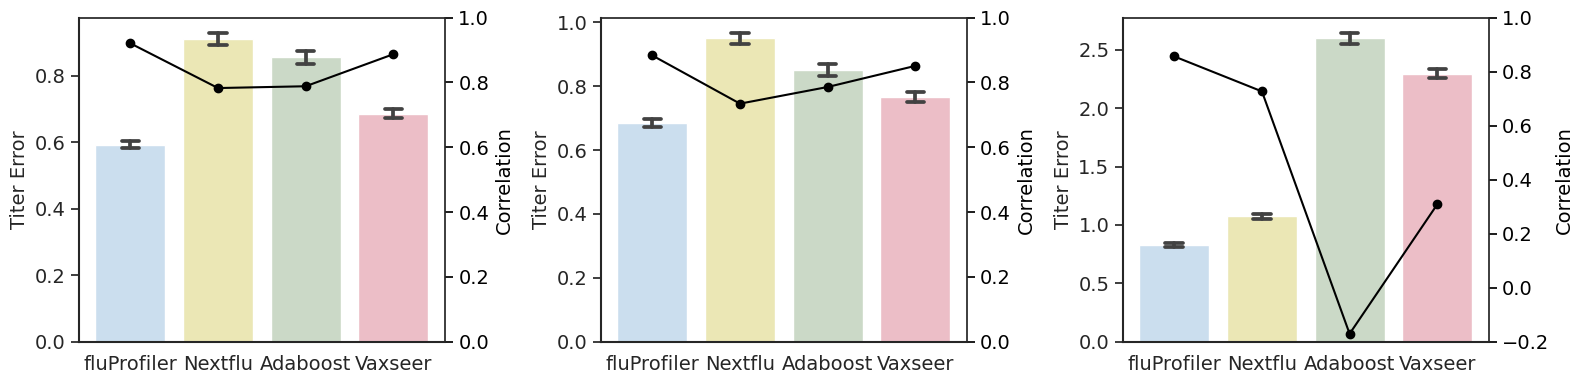

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statannotations.Annotator import Annotator
from scipy.stats import pearsonr

sns.set(style='white')

pairs = [
    ("fluProfiler", "Nextflu"),
    ("fluProfiler", "Adaboost"),
    ("Nextflu", "Adaboost"),
    ("fluProfiler", "Vaxseer"),
    ("Nextflu", "Vaxseer"),
    ("Adaboost", "Vaxseer"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

datasets = [
    (df_titer, axes[0], 'divided by titer', "titer"),
    (df_strain, axes[1], 'divided by strain', "strain"),
    (df_serum, axes[2], 'divided by serum', "serum"),
]

# 每个子图的相关性（长度=3）
correlations = {
    "titer":  [pearsonr(fluProfiler_titer['label'], fluProfiler_titer['prediction'])[0], 
    pearsonr(Nextflu_titer['label'], Nextflu_titer['pred_without_name'])[0], 
    pearsonr(Adaboost_titer['label'], Adaboost_titer['pred_without_name'])[0],
    pearsonr(vaxseer_titer['label'], vaxseer_titer['prediction'])[0]],
    "strain": [pearsonr(fluProfiler_strain['label'], fluProfiler_strain['prediction'])[0], 
    pearsonr(Nextflu_strain['label'], Nextflu_strain['pred_without_name'])[0], 
    pearsonr(Adaboost_strain['label'], Adaboost_strain['pred_without_name'])[0],
    pearsonr(vaxseer_strain['label'], vaxseer_strain['prediction'])[0]],
    "serum": [pearsonr(fluProfiler_serum['label'], fluProfiler_serum['prediction'])[0], 
    pearsonr(Nextflu_serum['label'], Nextflu_serum['pred_without_name'])[0], 
    pearsonr(Adaboost_serum['label'], Adaboost_serum['pred_without_name'])[0],
    pearsonr(vaxseer_serum['label'], vaxseer_serum['prediction'])[0]],
}

fixed_colors = ["#C5DFF4", "#F4EEAC", "#C9DCC4", "#F4B6C2"]

for df, ax, title, key in datasets:
    sns.barplot(
        x='model',
        y='value',
        data=df,
        estimator=np.mean,
        errorbar='ci',
        capsize=0.2,
        ax=ax,
        palette=fixed_colors   # ← 指定固定三色
    )

    # 格式美化
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.set_ylabel('Titer Error', fontsize=14)
    ax.set_xlabel('')
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # 右轴相关性曲线
    corr_list = correlations[key]
    ax2 = ax.twinx()
    ax2.plot(range(len(corr_list)), corr_list, color='black', marker='o', linestyle='-')
    ax2.set_ylabel("Correlation", fontsize=14, color='black')
    ax2.tick_params(axis='y', labelsize=14, colors='black')
    
    if key == "serum":
        ax2.set_ylim(-0.2, 1)   # 或者 (-1, 1)
    else:
        ax2.set_ylim(0, 1)

    ax2.set_xticks(range(len(corr_list)))
    xticklabels = [m.replace('fluProfiler', 'fluAgPredictor') for m in df['model'].unique()]
    # ax2.set_xticklabels(xticklabels)
    # ax.set_xticklabels(xticklabels, rotation=45)

plt.tight_layout()
# plt.savefig('../Figure/Fig2BCD.svg')
plt.show()